In [1]:
# Clean imports without sensitivity analysis
import warnings
warnings.filterwarnings('ignore')

# Basic imports
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point, LineString, Polygon
import rasterio
from scipy.optimize import root_scalar
from rtree import index
import sys

# Add src directory to path
sys.path.append(str(Path.cwd().parent / 'src'))

# Import grid-based accessibility module
import grid_based_accessibility_hex as grid_hex


In [2]:
# Imports
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
import pickle
import hashlib
import rasterio
from scipy.optimize import root_scalar
from rtree import index
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(str(Path.cwd().parent / 'src'))

# Import repo modules
import grid_based_accessibility_hex as grid_hex
#TODO: import and run sensitivity analysis


In [3]:
# Helper functions for damage and repair calculations (from original function)
def default_damage_ratio_function(hazard_values, coefficients):
    """Calculate damage ratio from hazard values using linear function"""
    m, n = coefficients
    return m * hazard_values + n

def default_repair_time_function(damage_ratios, coefficients):
    """Calculate repair time from damage ratios using polynomial function"""
    a, b, c = coefficients
    return a * (damage_ratios ** 2) + b * damage_ratios + c

def solve_damage_ratio_from_repair_time(repair_time, coefficients):
    """
    Numerically solve for the damage ratio given a repair time and polynomial coefficients.
    repair_time = a * DR^2 + b * DR + c
    """
    a, b, c = coefficients
    # Define the function whose root we want to find
    def func(dr):
        return a * dr**2 + b * dr + c - repair_time
    # Solve for dr in [0, 1]
    try:
        sol = root_scalar(func, bracket=[0, 1], method='brentq')
        if sol.converged:
            return sol.root
        else:
            return 0.0  # or np.nan 
    except:
        return 0.0

In [4]:
# Functions
def vectorized_damage_ratio_solver(repair_times, coefficients):
    """
    Avoids looping through each repair time individually using a vectorized approach.
    
    Vectorized solver for quadratic function: repair_time = a*DR² + b*DR + c
    Solve for DR using quadratic formula

    Args:
        repair_times (np.ndarray): Array of repair times (for each asset).
        coefficients (tuple): Coefficients (a, b, c) of the quadratic equation.

    Returns:
        np.ndarray: Array of damage ratios (DR) corresponding to each repair time.
    """
    a, b, c = coefficients
    
    # Quadratic equation: a*DR² + b*DR + (c - repair_time) = 0
    # Using quadratic formula: DR = (-b ± √(b² - 4a(c-repair_time))) / 2a
    
    discriminant = b**2 - 4*a*(c - repair_times)
    
    # Handle negative discriminants (no real solution)
    valid_mask = discriminant >= 0
    damage_ratios = np.zeros_like(repair_times, dtype=np.float64)
    
    if np.any(valid_mask):
        sqrt_disc = np.sqrt(discriminant[valid_mask])
        # Take positive root (damage ratio should be positive)
        damage_ratios[valid_mask] = (-b + sqrt_disc) / (2*a)
    
    # Clamp to valid range [0, 1]
    return np.clip(damage_ratios, 0.0, 1.0)


In [5]:
def batch_extract_raster_values_optimized(hazard_map, asset_geometries, extraction_method='max'):
    """
    Batch extraction with single I/O operation, optimized for building footprint analysis.
    
    For building footprints, extracts statistical values (max, median, mean) from all pixels 
    within the building polygon or the centroid if (point).

    Args:
        hazard_map (str): Path to the raster hazard map file.
        asset_geometries (GeoDataFrame or GeoSeries): Geometries of assets to sample from the raster.
        extraction_method (str): Method for polygon aggregation:
            - 'max': Maximum value within polygon (default, good for flood risk)
            - 'median': Median value within polygon (robust to outliers)
            - 'mean': Mean value within polygon 
            - 'point': Point sampling (fastest, for point geometries or when precision isn't necessary)

    Returns:
        List[float]: List of sampled/aggregated raster values for each asset geometry.
                    Negative values, NaNs, and no-data are converted to 0.0.
    """
    import rasterio.mask
    from rasterio.features import rasterize
    
    with rasterio.open(hazard_map) as src:
        # Convert to correct CRS if needed
        if hasattr(asset_geometries, 'crs') and asset_geometries.crs != src.crs:
            asset_geometries = asset_geometries.to_crs(src.crs)
        
        # Handle different input types
        if hasattr(asset_geometries, 'geometry'):
            geometries = asset_geometries.geometry
        else:
            geometries = asset_geometries
        
        extracted_values = []
        
        if extraction_method == 'point':
            # Fast point sampling for point geometries or when high precision isn't needed
            coords = []
            for geom in geometries:
                if hasattr(geom, 'x') and hasattr(geom, 'y'):
                    # Point geometry
                    coords.append((geom.x, geom.y))
                else:
                    # Use centroid for polygons in point mode
                    centroid = geom.centroid
                    coords.append((centroid.x, centroid.y))
            
            # Batch sample - single I/O operation
            sampled_values = list(src.sample(coords))
            # Handle NaNs, negative values, and no-data
            return [v[0] if v.size > 0 and not np.isnan(v[0]) and v[0] >= 0 else 0.0 for v in sampled_values]
        
        else:
            # High-precision polygon-based extraction for buildings
            for geom in geometries:
                try:
                    if hasattr(geom, 'x') and hasattr(geom, 'y'):
                        # Point geometry - just sample the point
                        sampled = list(src.sample([(geom.x, geom.y)]))
                        value = sampled[0][0] if sampled and sampled[0].size > 0 and not np.isnan(sampled[0][0]) and sampled[0][0] >= 0 else 0.0
                        extracted_values.append(value)
                    
                    else:
                        # Polygon geometry - extract all pixels within the polygon
                        # Mask the raster with the polygon
                        masked_array, mask_transform = rasterio.mask.mask(src, [geom], crop=True, nodata=src.nodata)
                        
                        # Get the first band data
                        band_data = masked_array[0]
                        
                        # Remove nodata values and negative values
                        if src.nodata is not None:
                            valid_data = band_data[(band_data != src.nodata) & (~np.isnan(band_data)) & (band_data >= 0)]
                        else:
                            valid_data = band_data[(~np.isnan(band_data)) & (band_data >= 0)]
                        
                        # Calculate the requested statistic
                        if len(valid_data) > 0:
                            if extraction_method == 'max':
                                value = float(np.max(valid_data))
                            elif extraction_method == 'median':
                                value = float(np.median(valid_data))
                            elif extraction_method == 'mean':
                                value = float(np.mean(valid_data))
                            else:
                                # Default to max if unknown method
                                value = float(np.max(valid_data))
                        else:
                            # No valid data in polygon - fallback to centroid sampling
                            centroid = geom.centroid
                            sampled = list(src.sample([(centroid.x, centroid.y)]))
                            value = sampled[0][0] if sampled and sampled[0].size > 0 and not np.isnan(sampled[0][0]) and sampled[0][0] >= 0 else 0.0
                        
                        extracted_values.append(value)
                
                except Exception as e:
                    # Fallback to centroid sampling if polygon processing fails
                    print(f"Warning: Polygon extraction failed for geometry, using centroid: {e}")
                    try:
                        centroid = geom.centroid if hasattr(geom, 'centroid') else geom
                        coords = (centroid.x, centroid.y) if hasattr(centroid, 'x') else (geom.x, geom.y)
                        sampled = list(src.sample([coords]))
                        value = sampled[0][0] if sampled and sampled[0].size > 0 and not np.isnan(sampled[0][0]) and sampled[0][0] >= 0 else 0.0
                        extracted_values.append(value)
                    except Exception as e2:
                        print(f"Error sampling centroid: {e2}, using 0.0")
                        extracted_values.append(0.0)
        
        return extracted_values


In [6]:
# Test and compare functions
def compare_extraction_methods(hazard_map, asset_geometries, sample_size=5):
    """
    Compare different extraction methods for the same geometries.
    """
    methods = ['point', 'max', 'median', 'mean']
    comparison_results = {}
    
    print(f"Comparing extraction methods for {min(sample_size, len(asset_geometries))} sample geometries...")
    
    # Take a sample for comparison
    sample_geoms = asset_geometries.iloc[:sample_size] if hasattr(asset_geometries, 'iloc') else asset_geometries[:sample_size]
    
    for method in methods:
        print(f"  Testing {method} method...")
        values = batch_extract_raster_values_optimized(hazard_map, sample_geoms, extraction_method=method)
        comparison_results[method] = values
    
    # Display comparison
    print("\nExtraction Method Comparison:")
    print("Geometry | Point  | Max    | Median | Mean")
    print("-" * 45)
    
    for i in range(len(comparison_results['point'])):
        point_val = comparison_results['point'][i]
        max_val = comparison_results['max'][i]
        median_val = comparison_results['median'][i]
        mean_val = comparison_results['mean'][i]
        
        print(f"   {i:2d}    | {point_val:6.3f} | {max_val:6.3f} | {median_val:6.3f} | {mean_val:6.3f}")
    
    return comparison_results

print("Use compare_extraction_methods() to test different approaches with specific datasets")

Use compare_extraction_methods() to test different approaches with specific datasets


In [7]:
def create_spatial_index(dissolved_roads):
    """
    Create R-tree spatial index for fast spatial queries
    """
    # Build R-tree index
    idx = index.Index()
    
    # Insert each island's bounding box into the index
    for i, row in dissolved_roads.iterrows():
        bounds = row.geometry.bounds  # (minx, miny, maxx, maxy)
        idx.insert(i, bounds, obj=row)
    
    return idx

def find_nearest_island_rtree(asset_geom, spatial_idx, dissolved_roads):
    #TODO:implement fallback finding nearest island without index -> what happenes with nested islands? this could be problematic
    """
    Fast nearest neighbor search using R-tree
    """
    # Get candidates from spatial index (very fast)
    candidates = list(spatial_idx.nearest(asset_geom.bounds, 5))  # Get 5 nearest candidates
    
    # Calculate exact distances only for candidates (much fewer than all islands)
    min_distance = float('inf')
    nearest_island_id = None
    
    for candidate_idx in candidates:
        candidate_geom = dissolved_roads.iloc[candidate_idx].geometry
        distance = asset_geom.distance(candidate_geom)
        
        if distance < min_distance:
            min_distance = distance
            nearest_island_id = dissolved_roads.iloc[candidate_idx]['island_id']
    
    return nearest_island_id

print("Spatial indexing functions defined")

Spatial indexing functions defined


In [8]:
# Cache functions
def create_accessibility_cache_key(hazard_map, flood_threshold, accessibility_model, hazard_dir=None):
    """
    Create a cache key for accessibility results by combining hazard map, flood threshold, and model signature.
    """
    # Get model signature for traceability
    model_signature = f"{accessibility_model.__module__}.{accessibility_model.__name__}"
    if hasattr(accessibility_model, '__version__'):
        model_signature += f"_v{accessibility_model.__version__}"
    
    # Get hazard directory name for cache segregation
    if hazard_dir is not None:
        hazard_dir_name = Path(hazard_dir).name
    else:
        # Extract from hazard map path
        hazard_dir_name = Path(hazard_map).parent.name
    
    # Create cache key with hazard directory
    hazard_file = Path(hazard_map).name
    cache_key = f"{hazard_dir_name}_{hazard_file}_{flood_threshold}_{model_signature}"
    
    return cache_key

def load_accessibility_cache(cache_dir, hazard_dir=None):
    """Load existing accessibility cache from interim directory"""
    # Create cache filename with hazard directory name
    if hazard_dir is not None:
        hazard_dir_name = Path(hazard_dir).name
    else:
        hazard_dir_name = "unknown"
    
    cache_file = cache_dir / f"accessibility_cache_{hazard_dir_name}.pkl"
    
    if cache_file.exists():
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    return {}

def save_accessibility_cache(cache_dict, cache_dir, hazard_dir=None):
    """Save accessibility cache to interim directory"""
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    # Create cache filename with hazard directory name
    if hazard_dir is not None:
        hazard_dir_name = Path(hazard_dir).name
    else:
        hazard_dir_name = "unknown"
    
    cache_file = cache_dir / f"accessibility_cache_{hazard_dir_name}.pkl"
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    print(f"Accessibility cache saved to {cache_file}")


In [20]:
# Island assignment functions 
def match_island_ids_assets(gdf_assets, hazard_threshold, hazard_column):
    """
    Assign assets to road network islands based on flooding.
    
    Load the hazard graph with flood data, filter edges based on hazard threshold to remove flooded roads
    Find connected components (islands) in the remaining road network
    Assign each asset to its nearest island using distance to road network lines
    
    Args:
        gdf_assets (GeoDataFrame): Assets to assign to islands
        hazard_threshold (float): Flood depth threshold for road passability
        hazard_column (str): Column name containing hazard values (e.g., 'EV0_ma')
    
    Returns:
        tuple: (gdf_assets with island_id column, dissolved_roads GeoDataFrame with line geometries)
    """
    try:
        # Get project paths
        root_dir = Path.cwd().parent
        hazard_graph_path = root_dir / 'data' / 'static' / 'output_graph' / 'base_graph_hazard_editted.p'
        
        if not hazard_graph_path.exists():
            print(f"Warning: Hazard graph not found at {hazard_graph_path}")
            print("Falling back to simple island assignment")
            return _simple_island_fallback(gdf_assets)
        
        print(f"Computing islands from graph: threshold={hazard_threshold}, column={hazard_column}")
        
        # Use the grid_based_accessibility module function to compute islands
        islands_gdf = grid_hex.compute_island_geodataframe_from_graph(
            str(hazard_graph_path), 
            hazard_threshold, 
            hazard_column
        )
        islands_gdf = islands_gdf.drop_duplicates(subset=["geometry", "island_id"])

        # Dissolve roads by island_id to get road network per island
        dissolved_roads = islands_gdf.dissolve(by='island_id', as_index=False)

        if len(dissolved_roads) == 0:
            print("WARNING: No road islands found, using fallback")
            return _simple_island_fallback(gdf_assets)
        
        # We'll assign assets to islands based on distance to road network
        print(f"Found {len(dissolved_roads)} road network islands")
        
        # Ensure assets are in the same CRS as road islands
        assets_gdf = gdf_assets.copy()
        if assets_gdf.crs != dissolved_roads.crs:
            assets_gdf = assets_gdf.to_crs(dissolved_roads.crs)
        
        # Assign each asset to the nearest island (by distance to road network)
        asset_island_ids = []
        
        for idx, asset_geom in enumerate(assets_gdf.geometry):
            try:
                # Get asset point (use centroid for polygons)
                if hasattr(asset_geom, 'centroid'):
                    asset_point = asset_geom.centroid
                else:
                    asset_point = asset_geom
                
                # Find nearest road island by distance
                distances = dissolved_roads.geometry.distance(asset_point)
                nearest_idx = distances.idxmin()
                island_id = dissolved_roads.iloc[nearest_idx]['island_id']
                
                asset_island_ids.append(island_id)
                
            except Exception as e:
                print(f"Warning: Error assigning asset {idx} to island: {e}")
                # Assign to island -1 as fallback
                asset_island_ids.append(-1)
        
        # Add island assignments to assets
        assets_gdf['island_id'] = asset_island_ids
        
        # Return in original CRS
        if assets_gdf.crs != gdf_assets.crs:
            assets_gdf = assets_gdf.to_crs(gdf_assets.crs)
            dissolved_roads = dissolved_roads.to_crs(gdf_assets.crs)
        
        print(f"Successfully assigned {len(assets_gdf)} assets to {len(dissolved_roads)} road network islands")
        
        return assets_gdf, dissolved_roads
        
    except Exception as e:
        print(f"Error in island assignment: {e}")
        print("Using simple fallback island assignment")
        return _simple_island_fallback(gdf_assets)

def _simple_island_fallback(gdf_assets):
    """
    Simple fallback when real island computation fails.
    """
    print("WARNING! Using simple single-island fallback")
    
    # Assign all assets to island 0
    gdf_assets = gdf_assets.copy()
    gdf_assets['island_id'] = 0
    
    # Create a simple dissolved roads placeholder
    dissolved_roads = gpd.GeoDataFrame({
        'island_id': [0],
        'island_size_km': [100.0],
        'geometry': [gdf_assets.geometry.unary_union.convex_hull]
    }, crs=gdf_assets.crs)
    
    return gdf_assets, dissolved_roads

# update_repair_crew_islands_with_overlap should be here?

def precompute_island_assignments(gdf_assets, hazard_thresholds, hazard_columns, interim_dir):
    """
    Pre-compute island assignments for all expected scenarios

    Args:
        gdf_assets (GeoDataFrame): Assets to assign to islands
        hazard_thresholds (list): List of hazard thresholds to consider
        hazard_columns (list): List of hazard columns to consider

    Returns:
        dict: Dictionary mapping (threshold, column) to island assignments and dissolved roads
    """
    island_cache_file = interim_dir / "island_assignments_cache.pkl"
    
    if island_cache_file.exists():
        print(f"Loading cached island assignments from {island_cache_file}")
        with open(island_cache_file, 'rb') as f:
            return pickle.load(f)
    
    print("Pre-computing island assignments for all scenarios...")
    island_lookup = {}
    
    for threshold in tqdm(hazard_thresholds, desc="Thresholds"):
        for col in tqdm(hazard_columns, desc="Columns", leave=False):
            cache_key = f"{threshold}_{col}"
            
            try:
                temp_gdf, dissolved_roads = match_island_ids_assets(
                    gdf_assets.copy(), threshold, col
                )
                
                # Create spatial index for fast lookups
                spatial_idx = create_spatial_index(dissolved_roads)
                
                # Store both the assignments and dissolved roads with spatial index
                island_lookup[cache_key] = {
                    'island_ids': temp_gdf['island_id'].values,
                    'dissolved_roads': dissolved_roads,
                    'spatial_index': spatial_idx
                }
                
            except Exception as e:
                print(f"Warning: Failed to compute islands for {cache_key}: {e}")
                continue
    
    # Save to interim directory
    interim_dir.mkdir(parents=True, exist_ok=True)
    
    # Save without spatial index (can't pickle rtree index easily)
    save_dict = {}
    for key, data in island_lookup.items():
        save_dict[key] = {
            'island_ids': data['island_ids'],
            'dissolved_roads': data['dissolved_roads']
        }
    
    with open(island_cache_file, 'wb') as f:
        pickle.dump(save_dict, f)
    
    print(f"Island assignments cache saved to {island_cache_file}")
    
    # Rebuild spatial indices
    for key, data in island_lookup.items():
        if 'spatial_index' not in data:
            data['spatial_index'] = create_spatial_index(data['dissolved_roads'])
    
    return island_lookup

def load_island_assignments(interim_dir):
    """Load and rebuild island assignments cache with spatial indices"""
    island_cache_file = interim_dir / "island_assignments_cache.pkl"
    
    if not island_cache_file.exists():
        return {}
    
    with open(island_cache_file, 'rb') as f:
        island_lookup = pickle.load(f)
    
    # Rebuild spatial indices
    for key, data in island_lookup.items():
        data['spatial_index'] = create_spatial_index(data['dissolved_roads'])
    
    return island_lookup

print("Island assignment caching functions defined")

Island assignment caching functions defined


In [10]:
def find_hazard_value_at_points_optimized(hazard_map, gdf, day_counter, extraction_method='max'):
    """
    Batch raster extraction with building footprint analysis and fallback centroid sampling.
        
    Args:
        hazard_map (str): Path to hazard raster file
        gdf (GeoDataFrame): Asset geometries 
        day_counter (int): Day number for column naming
        extraction_method (str): 'max' (default), 'median', 'mean', or 'point'
    
    Returns:
        GeoDataFrame: Updated GDF with hazard values
    """
    # Determine the hazard value column name based on day
    hazval_str = f'EV{day_counter}_ma'
    
    # Use enhanced batch extraction with building footprint analysis
    print(f"Extracting hazard values using '{extraction_method}' method for {len(gdf)} assets...")
    
    hazard_values = batch_extract_raster_values_optimized(
        hazard_map, 
        gdf.geometry, 
        extraction_method=extraction_method
    )
    
    gdf[hazval_str] = hazard_values
    
    # Log statistics for verification
    non_zero_count = sum(1 for v in hazard_values if v > 0)
    max_hazard = max(hazard_values) if hazard_values else 0
    mean_hazard = sum(hazard_values) / len(hazard_values) if hazard_values else 0
    
    print(f"  Hazard extraction complete: {non_zero_count}/{len(hazard_values)} assets with hazard > 0")
    print(f"  Max hazard value: {max_hazard:.3f}, Mean: {mean_hazard:.3f}")
    
    return gdf

# Configuration function for setting extraction method globally
def set_hazard_extraction_method(method='max'):
    """
    Set the global hazard extraction method for the simulation.
    
    Args:
        method (str): 'max', 'median', 'mean', or 'point'
    """
    global HAZARD_EXTRACTION_METHOD
    HAZARD_EXTRACTION_METHOD = method
    print(f"Hazard extraction method set to: {method}")
    
    if method == 'max':
        print("  → Will use maximum hazard value within each building footprint")
        print("  → Best for flood risk assessment (worst-case scenario)")
    elif method == 'median':
        print("  → Will use median hazard value within each building footprint")
        print("  → Robust to outliers, good for general assessment")
    elif method == 'mean':
        print("  → Will use mean hazard value within each building footprint") 
        print("  → Average conditions across building")
    elif method == 'point':
        print("  → Will use point sampling at building centroids")
        print("  → Fastest method, good for quick analysis")

# Set default extraction method
HAZARD_EXTRACTION_METHOD = 'max'

print("Enhanced hazard value extraction function defined")
print("Default extraction method: 'max' (maximum value within building footprint)")
print("Use set_hazard_extraction_method('median'|'mean'|'point') to change")

Enhanced hazard value extraction function defined
Default extraction method: 'max' (maximum value within building footprint)
Use set_hazard_extraction_method('median'|'mean'|'point') to change


In [11]:
def update_repair_crew_assignment_optimized(timestep, available_repair_crews, repair_crews_assigned, 
                                           accessible, flooded_mask, repair_time, island_ids=None, method=None, verbose=False):    
    """
    Update repair crew assignments based on accessibility, operational status, and repair time.
    
    MATCHES ORIGINAL FUNCTION SIGNATURE: update_repair_crew_assignment(day_counter_str, available_repair_crews, 
                                         repair_crews_assigned, accessible, flooded_mask, repair_time, island_ids, 
                                         method=repair_crew_assignment_method, verbose=verbose)

    Args:
        timestep (str or int): Current timestep/day in the simulation (matches day_counter_str from original).
        available_repair_crews (int or dict): Number of available repair crews or a dictionary with island IDs as keys.
        repair_crews_assigned (np.ndarray): Boolean array indicating which assets already have repair crews assigned.
        accessible (np.ndarray): Boolean array indicating which assets are accessible.
        flooded_mask (np.ndarray): Boolean array indicating which assets are flooded (matches original parameter name).
        repair_time (np.ndarray): Array of remaining repair times for each asset.
        island_ids (np.ndarray, optional): Array of island IDs for each asset, if available.
        method (str, optional): Method for assigning repair crews (matches repair_crew_assignment_method from original):
            - 'random': Random assignment
            - 'lowest repair time': Assign to assets with lowest remaining repair time
            - 'highest repair time': Assign to assets with highest remaining repair time
        verbose (bool, optional): If True, print detailed assignment information.

    Returns:
        tuple: (updated available repair crews, updated repair crews assigned array)
            updated available repair crews can be an int or a dictionary with island IDs as keys.
            updated repair crews assigned is a boolean array indicating which assets have repair crews assigned.
    
    """
    
    # Check if available repair crews is None, meaning no constraints
    if available_repair_crews is None:
        # If no constraints, assign all repairable assets
        repair_crews_assigned[:] = True
        if verbose:
            print("No constraints on repair crews, all assets are assigned for repair.")
        return available_repair_crews, repair_crews_assigned 
    
    # If available_repair_crews is a dictionary, it means we have island-based constraints
    if isinstance(available_repair_crews, dict):
        # Assign repair crews based on island IDs
        for island_id, crew_count in available_repair_crews.items():
            if crew_count > 0:  # for each island with available crews
                if island_ids is not None: # If assets have island IDs, only assign to assets in that island
                    island_mask = (island_ids == island_id)
                    repairable_assets = accessible & ~flooded_mask & (repair_time > 0) & island_mask & ~repair_crews_assigned
                else:
                    repairable_assets = accessible & ~flooded_mask & (repair_time > 0) & ~repair_crews_assigned

                if repairable_assets.sum() <= crew_count: # More crews than assets needing assignment
                    newly_assigned_crews = repairable_assets.sum()
                    repair_crews_assigned[repairable_assets] = True
                    available_repair_crews[island_id] -= newly_assigned_crews
                    
                    if verbose and newly_assigned_crews > 0:
                        print(f"Assigned {newly_assigned_crews} repair crews to island {island_id}")
                else: # If there are more repairable assets than available crews, assign based on method
                    if verbose:
                        print(f"Assigning repair crews to island {island_id} with {crew_count} available crews and {repairable_assets.sum()} repairable assets")
                    
                    repairable_assets_indices = np.where(repairable_assets)[0]
                    if method is None or method == 'random' or method == 'islands':
                        np.random.shuffle(repairable_assets_indices)
                        repair_crews_assigned[repairable_assets_indices[:crew_count]] = True
                    elif 'lowest repair time' in method:
                        sorted_indices = np.argsort(repair_time[repairable_assets])
                        repair_crews_assigned[repairable_assets_indices[sorted_indices[:crew_count]]] = True
                    elif 'highest repair time' in method:
                        sorted_indices = np.argsort(-repair_time[repairable_assets])
                        repair_crews_assigned[repairable_assets_indices[sorted_indices[:crew_count]]] = True
                    
                    newly_assigned_crews = crew_count
                    available_repair_crews[island_id] -= newly_assigned_crews
                    
                    if verbose:
                        print(f"Assigned {newly_assigned_crews} repair crews to island {island_id} based on method '{method}'")

        # Return the updated assignment
        return available_repair_crews, repair_crews_assigned

    # If available_repair_crews is an int, we have a global constraint
    if available_repair_crews == 0:
        print("No available repair crews, cannot assign any assets for repair.")
        return available_repair_crews, repair_crews_assigned 
    
    if available_repair_crews > 0:
        print(f"Available repair crews: {available_repair_crews}, proceeding with assignment...")
        
        repairable_assets = accessible & ~flooded_mask & (repair_time > 0) & ~repair_crews_assigned

        if not 'islands' in str(method):  # Convert method to string to handle None case
            # If there are more repair crews than assets needing assignment, assign all repairable assets
            if repairable_assets.sum() <= available_repair_crews:
                newly_assigned_crews = repairable_assets.sum()
                repair_crews_assigned[repairable_assets] = True
                available_repair_crews -= newly_assigned_crews

                print(f"Assigned {newly_assigned_crews} repair crews to all repairable assets; There remain {available_repair_crews} available repair crews")
                
                return available_repair_crews, repair_crews_assigned
            
            # If there are fewer repair crews than assets needing assignment
            repairable_assets_indices = np.where(repairable_assets)[0]
            if method is None or method == 'random':
                np.random.shuffle(repairable_assets_indices)
                repair_crews_assigned[repairable_assets_indices[:available_repair_crews]] = True
            elif method == 'lowest repair time':
                sorted_indices = np.argsort(repair_time[repairable_assets])
                repair_crews_assigned[repairable_assets_indices[sorted_indices[:available_repair_crews]]] = True
            elif method == 'highest repair time':
                sorted_indices = np.argsort(-repair_time[repairable_assets])
                repair_crews_assigned[repairable_assets_indices[sorted_indices[:available_repair_crews]]] = True
            
            newly_assigned_crews = available_repair_crews
            available_repair_crews -= newly_assigned_crews
                
            if verbose:
                print(f"Assigned {newly_assigned_crews} repair crews to assets based on method '{method}'")
                print(f"->there remain {repairable_assets.sum() - newly_assigned_crews} repairable assets with no crews assigned")

            return available_repair_crews, repair_crews_assigned

        else:
            print("Method not implemented yet, returning current assignment.")
            return available_repair_crews, repair_crews_assigned
    
    return available_repair_crews, repair_crews_assigned


In [12]:
def update_repair_crew_islands_with_overlap(available_repair_crews, island_ids, dissolved_roads, previous_dissolved_roads=None, buffer_distance=1):
    """
    Update repair crew distribution across islands with geometric overlap analysis.
    
    Args:
        available_repair_crews: int (initial distribution) or dict (existing distribution)
        island_ids: Array of island assignments for assets
        dissolved_roads: GeoDataFrame of current dissolved road islands
        previous_dissolved_roads: GeoDataFrame of previous dissolved road islands (for overlap analysis)
        buffer_distance: Buffer distance for overlap calculations (default: 1 meter)
    
    Returns:
        dict: Crew distribution by island ID
    """
    present_islands = dissolved_roads.copy()
    unique_islands = np.unique(island_ids)
    
    # Remove any NaN islands
    unique_islands = unique_islands[~pd.isna(unique_islands)]
    
    print(f"Processing {len(unique_islands)} islands with crew distribution...")
    
    if isinstance(available_repair_crews, int):
        # Initial distribution: probabilistic assignment based on island sizes
        print(f"Initial distribution of {available_repair_crews} crews across {len(unique_islands)} islands")
        
        if len(unique_islands) == 0:
            return {}
        
        # Calculate island sizes for probabilistic assignment
        island_sizes = []
        for island in unique_islands:
            island_mask = island_ids == island
            asset_count = np.sum(island_mask)
            island_sizes.append(asset_count)
        
        total_assets = sum(island_sizes)
        
        if total_assets > 0:
            # Probabilistic assignment based on relative island sizes
            probabilities = np.array(island_sizes) / total_assets
            
            # Use multinomial distribution for crew assignment
            assigned_crews = np.random.choice(
                unique_islands, 
                size=available_repair_crews, 
                p=probabilities, 
                replace=True
            )
            
            unique_assigned, crew_counts = np.unique(assigned_crews, return_counts=True)
            available_repair_crews_by_island = {island: 0 for island in unique_islands}
            for island, count in zip(unique_assigned, crew_counts):
                available_repair_crews_by_island[island] = count
        
        # VALIDATION: Ensure total crews match input
        total_distributed = sum(available_repair_crews_by_island.values())
        if total_distributed != available_repair_crews:
            print(f"Warning: Crew distribution mismatch. Input: {available_repair_crews}, Distributed: {total_distributed}")
                
        print(f"Initial crew distribution by (island, crews): {[(island, crews) for island, crews in available_repair_crews_by_island.items() if crews > 0]}")
        return available_repair_crews_by_island
    
    elif isinstance(available_repair_crews, dict) and previous_dissolved_roads is not None:
        print("Performing overlap-based crew redistribution...")
        
        # VALIDATION: Track input crew total
        input_total_crews = sum(available_repair_crews.values())
        
        # Handle CRS: set a default CRS if none exists
        current_islands = present_islands.copy()
        previous_islands = previous_dissolved_roads.copy()
        
        # Set CRS if not present (assume EPSG:28992 for Netherlands)
        if current_islands.crs is None:
            current_islands = current_islands.set_crs('EPSG:28992')
        if previous_islands.crs is None:
            previous_islands = previous_islands.set_crs('EPSG:28992')
            
        # Ensure both GeoDataFrames have the same CRS
        current_islands = current_islands.to_crs('EPSG:28992')
        previous_islands = previous_islands.to_crs('EPSG:28992')
        
        # Apply buffers to both current and previous islands
        current_islands_buffered = current_islands.copy()
        current_islands_buffered['geometry'] = current_islands.geometry.buffer(buffer_distance)
        
        previous_islands_buffered = previous_islands.copy()  
        previous_islands_buffered['geometry'] = previous_islands.geometry.buffer(buffer_distance)
        
        # Initialize new crew distribution
        new_crew_distribution = {island: 0 for island in current_islands['island_id']}
        total_redistributed_crews = 0
        
        # For each previous island with crews, redistribute based on overlap
        for prev_island_id, crew_count in available_repair_crews.items():
            if crew_count <= 0:
                continue
                
            # Get buffered previous island geometry
            prev_island_geom = previous_islands_buffered[previous_islands_buffered['island_id'] == prev_island_id]
            if prev_island_geom.empty:
                print(f"Previous island {prev_island_id} not found, crews will be redistributed to nearest island")
                # Find nearest current island by centroid distance
                if not current_islands.empty:
                    # Use first current island as fallback
                    print(f"No geometry found for previous island {prev_island_id}, assigning crews to first current island")
                    nearest_island_id = current_islands.iloc[0]['island_id']
                    new_crew_distribution[nearest_island_id] += crew_count
                    total_redistributed_crews += crew_count
                continue
                
            prev_geom = prev_island_geom.geometry.iloc[0]
            
            # Calculate overlaps with all current buffered islands
            overlaps = {}
            total_overlap_area = 0
            
            for _, current_island in current_islands_buffered.iterrows():
                current_island_id = current_island['island_id']
                current_geom = current_island.geometry
                
                # Calculate intersection area between buffered geometries
                try:
                    intersection = prev_geom.intersection(current_geom)
                    if not intersection.is_empty:
                        overlap_area = intersection.area
                        overlaps[current_island_id] = overlap_area
                        total_overlap_area += overlap_area
                except Exception as e:
                    print(f"Error calculating overlap between islands {prev_island_id} and {current_island_id}: {e}")
                    continue
            
            if total_overlap_area > 0:
                # Distribute crews proportionally based on overlap areas
                crews_distributed_this_island = 0
                for current_island_id, overlap_area in overlaps.items():
                    # Calculate proportions for multinomial distribution
                    overlap_proportions = []
                    overlap_island_ids = []
                    
                    for island_id, area in overlaps.items():
                        overlap_proportions.append(area / total_overlap_area)
                        overlap_island_ids.append(island_id)
                    
                    # Use multinomial distribution for crew assignment
                    if len(overlap_island_ids) > 0:
                        assigned_crews = np.random.choice(
                            overlap_island_ids,
                            size=crew_count,
                            p=overlap_proportions,
                            replace=True
                        )
                        
                        unique_assigned, crew_counts = np.unique(assigned_crews, return_counts=True)
                        for island_id, count in zip(unique_assigned, crew_counts):
                            new_crew_distribution[island_id] += count
                            crews_distributed_this_island += count

                crew_difference = crew_count - crews_distributed_this_island
                if crew_difference != 0 and overlaps:
                    # Assign remaining crews to island with largest overlap
                    largest_overlap_island = max(overlaps.keys(), key=lambda x: overlaps[x])
                    new_crew_distribution[largest_overlap_island] += crew_difference
                    crews_distributed_this_island += crew_difference

                total_redistributed_crews += crews_distributed_this_island

                overlaps_areas = {island: (area/total_overlap_area)*100 for island, area in overlaps.items() if area > 0}
                print(f"Redistributed {crew_count} crews from previous island {prev_island_id} based on overlaps: {overlaps_areas}")
            else:
                # No overlap found, assign to nearest island by centroid distance
                print(f"No overlap found for previous island {prev_island_id}, assigning to nearest current island")
                
                if not current_islands.empty:
                    prev_centroid = prev_geom.centroid
                    distances = current_islands.geometry.centroid.distance(prev_centroid)
                    nearest_island_idx = distances.idxmin()
                    nearest_island_id = current_islands.loc[nearest_island_idx, 'island_id']
                    
                    new_crew_distribution[nearest_island_id] += crew_count
                    total_redistributed_crews += crew_count
                    print(f"Assigned {crew_count} crews to nearest island {nearest_island_id}")
        
        # VALIDATION: Ensure total crews are conserved
        if total_redistributed_crews != input_total_crews:
            print(f"Crew redistribution mismatch. Input: {input_total_crews}, Redistributed: {total_redistributed_crews}")
        
        print(f"Overlap-based crew redistribution complete: {[(island, crews) for (island, crews) in new_crew_distribution.items() if crews > 0]}")
        print(f"Total crews redistributed: {total_redistributed_crews}")
        
        return new_crew_distribution
    
    elif isinstance(available_repair_crews, dict):
        # Already a dictionary but no previous islands for overlap analysis
        # Just ensure all current islands are represented
        current_crew_distribution = {island: 0 for island in unique_islands}
        for island_id, crew_count in available_repair_crews.items():
            if island_id in current_crew_distribution:
                current_crew_distribution[island_id] = crew_count
            else:
                # Redistribute orphaned crews to existing islands
                if current_crew_distribution:
                    # Add to first available island
                    first_island = list(current_crew_distribution.keys())[0]
                    current_crew_distribution[first_island] += crew_count
                    print(f"Warning! Redistributed {crew_count} crews from missing island {island_id} to island {first_island}")
        
        print(f"Updated crew distribution: {current_crew_distribution}")
        return current_crew_distribution
    
    else:
        # Fallback: treat as initial distribution
        print("Unexpected crew distribution format, treating as initial distribution")
        return update_repair_crew_islands_with_overlap(len(unique_islands) * 2, island_ids, dissolved_roads)



In [13]:
# Main function to run simulation
def simulate_asset_damage_recovery_access_optimized(
    gdf_assets, 
    hazard_maps, 
    number_repair_crews=15, 
    repair_crew_assignment_method='lowest repair time',
    flood_threshold=0.2, 
    recovery_parameters=None,
    root_dir=None,
    verbose=False
):
    """
    Run the asset damage recovery simulation with accessibility and repair crew assignment.

    Args:
        gdf_assets (GeoDataFrame): GeoDataFrame containing asset geometries and initial states
        hazard_maps (list): List of paths to hazard map files (raster format)
        number_repair_crews (int): Total number of repair crews available for the simulation
        repair_crew_assignment_method (str): Method for assigning repair crews:
            - 'random': Random assignment
            - 'lowest repair time': Assign to assets with lowest remaining repair time
            - 'highest repair time': Assign to assets with highest remaining repair time
            - 'island': Assign based on pre-computed island assignments
            - 'islands lowest repair time': Assign to assets with lowest remaining repair time within islands
            - 'islands highest repair time': Assign to assets with highest remaining repair time within islands
        flood_threshold (float): Threshold for flooding to determine asset accessibility
        recovery_parameters (dict, optional): Dictionary containing recovery parameters:
            - 'repair_time_coefficients': Coefficients for calculating repair time based on damage ratio
            - 'damage_ratio_coefficients': Coefficients for calculating damage ratio based on hazard values
            - 'time_step_hours': Time step in hours for the simulation
            - 'damage_threshold': Threshold for damage ratio to consider asset damaged
            - 'repair_threshold': Threshold for repairable damage ratio
        root_dir (str or Path, optional): Root directory for data storage and caching
        verbose (bool): If True, print detailed simulation information

    Returns:
        dataframe: DataFrame containing simulation results by timestep
        dict: Simulation results including asset states, repair crew assignments, and accessibility
    """
    
    # Initialize paths and caching
    if root_dir is None:
        root_dir = Path.cwd().parent
    else:
        root_dir = Path(root_dir)
    
    interim_dir = root_dir / 'data' / 'interim'
    interim_dir.mkdir(parents=True, exist_ok=True)
    
    # Determine hazard directory from first hazard map for cache naming
    if hazard_maps:
        hazard_dir = Path(hazard_maps[0]).parent
        hazard_dir_name = hazard_dir.name
        print(f"Using hazard directory for cache naming: {hazard_dir_name}")
    else:
        hazard_dir = None
        hazard_dir_name = "unknown"
    
    # Load caches with hazard directory context
    print("Loading optimization caches...")
    accessibility_cache = load_accessibility_cache(interim_dir, hazard_dir)
    
    # Pre-compute island assignments if using island-based method
    island_cache = {}
    if 'island' in repair_crew_assignment_method:
        print("Pre-computing island assignments...")
        hazard_thresholds = [0.1, 0.2, 0.3, 0.4]  # Expected thresholds
        hazard_columns = [f'EV{i}_ma' for i in range(10)]  # Expected columns
        
        # Add hazard directory name to island cache filename
        island_cache = precompute_island_assignments(
            gdf_assets, hazard_thresholds, hazard_columns, interim_dir
        )
    
    # Set up default recovery parameters if not provided
    if recovery_parameters is None:
        recovery_parameters = {
            'repair_time_coefficients': [702.72, 3.14, 1.9891],
            'damage_ratio_coefficients': (0.0468, 0.0077),  # Added damage ratio coefficients
            'time_step_hours': 1,
            'damage_threshold': 0.001,
            'repair_threshold': 2.0  # Default threshold for repairable damage ratio
        }
    
    repair_time_coefficients = recovery_parameters['repair_time_coefficients']
    damage_ratio_coefficients = recovery_parameters.get('damage_ratio_coefficients', (0.0468, 0.0077))
    time_step_hours = recovery_parameters['time_step_hours']
    damage_threshold = recovery_parameters['damage_threshold']
    repair_threshold = recovery_parameters['repair_threshold']

    # Initialize simulation arrays
    num_assets = len(gdf_assets)
    
    # State arrays - following original function initialization
    damage_ratio = np.zeros(num_assets, dtype=np.float64)
    repair_time = np.zeros(num_assets, dtype=np.float64)
    accessible = np.ones(num_assets, dtype=bool)  # Start as accessible
    operational = np.ones(num_assets, dtype=bool)  # All start operational
    repair_crews_assigned = np.zeros(num_assets, dtype=bool)
    current_hazard_values = np.zeros(num_assets, dtype=np.float64)
    island_ids = np.zeros(num_assets, dtype=int)  # Placeholder for island ids if needed
    previous_islands = None
    
    # Create temporary GeoDataFrame for hazard value extraction
    temp_gdf = gdf_assets.copy()
    
    # Results tracking
    results = []
    
    # Initialize grid analysis once
    print("Initializing grid-based accessibility analysis...")
    grid_hex.initialize_grid_analysis(root_dir)
    
    # Simulation loop - following original function structure with daily processing
    available_repair_crews = number_repair_crews
    
    # Convert hazard maps to timesteps
    timesteps = np.arange(0, len(hazard_maps) * 24)  # 24 hours per day
    
    for timestep in timesteps:
        day_counter = timestep // 24
        day_counter_str = str(day_counter).zfill(2)
        
        # Every 24 hour-timesteps, process the hazard map for that day
        if timestep % 24 == 0:
            if day_counter >= len(hazard_maps):
                break  # No more hazard maps available
                
            hazard_map = hazard_maps[day_counter]
            haz_col_str = f'EV{day_counter}_ma'
            
            if verbose:
                print(f"\n=== Processing timestep {timestep} (day {day_counter}) ===")
            
            # Update hazard values
            temp_gdf = find_hazard_value_at_points_optimized(
                hazard_map, 
                temp_gdf, 
                day_counter, 
                extraction_method=HAZARD_EXTRACTION_METHOD
            )
            haz_val_str = f'hazard_value_{day_counter_str}'
            if haz_val_str in temp_gdf.columns:
                current_hazard_values = temp_gdf[haz_val_str].fillna(0.0).values
            else:
                current_hazard_values = temp_gdf[haz_col_str].fillna(0.0).values
            
            # Island-based crew management
            if 'island' in repair_crew_assignment_method:
                cache_key = f"{flood_threshold}_{haz_col_str}"
                if cache_key in island_cache:
                    island_data = island_cache[cache_key]
                    island_ids = island_data['island_ids']
                    dissolved_roads = island_data['dissolved_roads']
                    
                    # Update crew distribution with overlap analysis
                    available_repair_crews = update_repair_crew_islands_with_overlap(
                        available_repair_crews, 
                        island_ids, 
                        dissolved_roads, 
                        previous_islands
                    )
                    
                    # Store current islands for next iteration
                    previous_islands = dissolved_roads.copy()
                    
                    # Assign island_ids to temp_gdf
                    temp_gdf['island_id'] = island_ids
                else:
                    print(f"Warning: No cached islands for {cache_key}, using global crew assignment")
            
            # Using masks to only update necessary states
            flooded_mask = current_hazard_values > flood_threshold
            operational[flooded_mask] = False
            
            # For assets under repair, solve for current damage ratio
            repair_mask = repair_time > repair_threshold
            if np.any(repair_mask):
                repair_indices = np.where(repair_mask)[0]
                for idx in repair_indices:
                    damage_ratio[idx] = solve_damage_ratio_from_repair_time(
                        repair_time[idx], repair_time_coefficients
                    )
            
            # Update damage ratio for flooded assets (following original logic)
            if np.any(flooded_mask):
                # Use configurable damage ratio coefficients (matching original logic)
                dr_new = default_damage_ratio_function(current_hazard_values[flooded_mask], damage_ratio_coefficients)
                damage_ratio[flooded_mask] = np.maximum(damage_ratio[flooded_mask], dr_new)
            
            # Only recalculate repair time for assets with damage > 0 AND repair_time <= threshold
            damaged_mask = (damage_ratio > 0) & (repair_time <= repair_threshold)
            if np.any(damaged_mask):
                repair_time[damaged_mask] = default_repair_time_function(
                    damage_ratio[damaged_mask], repair_time_coefficients
                )

            
            # Daily accessibility update 
            cache_key = create_accessibility_cache_key(hazard_map, flood_threshold, grid_hex.accessibility_model, hazard_dir)
            
            if cache_key in accessibility_cache:
                accessible = accessibility_cache[cache_key]
                if verbose:
                    print(f"Using cached accessibility for day {day_counter} (hazard dir: {hazard_dir_name})")
            else:
                print(f"Computing accessibility for day {day_counter} (hazard dir: {hazard_dir_name})...")
                try:
                    accessibility_result = grid_hex.accessibility_model(
                        gdf_assets.geometry, 
                        hazard_map, 
                        current_hazard_values,
                        verbose=verbose,
                        day_string=day_counter_str,
                        project_root=root_dir
                    )
                    accessible = np.array(accessibility_result, dtype=bool)
                    accessibility_cache[cache_key] = accessible
                    
                    if verbose:
                        print(f"Accessibility updated for timestep {timestep} (day {day_counter})")
                        print(f"Accessible assets: {accessible.sum()} out of {num_assets}")
                except Exception as e:
                    print(f"Warning: Accessibility model failed: {e}")
                    print("Keeping current accessibility status")
        
        # Repair crew assignment
        available_repair_crews, repair_crews_assigned = update_repair_crew_assignment_optimized(
            timestep, 
            available_repair_crews, 
            repair_crews_assigned, 
            accessible, 
            current_hazard_values > flood_threshold,  # flooded_mask
            repair_time, 
            island_ids, 
            method=repair_crew_assignment_method, 
            verbose=verbose
        )
        
        # For each timestep, decrement repair_time if accessible and not flooded (following original logic)
        can_repair_mask = accessible & (current_hazard_values <= 0.0) & repair_crews_assigned
        repair_time[can_repair_mask] = np.maximum(repair_time[can_repair_mask] - 1, 0)
        
        # Check for completed repairs (following original logic)
        newly_operational = (repair_time == 0) & (~operational)
        
        if np.any(newly_operational):
            num_newly_operational = newly_operational.sum()
            
            # Update asset states
            operational[newly_operational] = True
            damage_ratio[newly_operational] = 0.0
            
            # Release repair crews - handle both integer and dictionary formats (following original logic)
            if available_repair_crews is not None:
                if isinstance(available_repair_crews, dict):
                    # For island-based constraints, add crews back to their respective islands
                    for asset_idx in np.where(newly_operational)[0]:
                        asset_island_id = island_ids[asset_idx]
                        if asset_island_id in available_repair_crews:
                            available_repair_crews[asset_island_id] += 1
                        else:
                            # If island not found, add to first available island
                            if available_repair_crews:
                                first_island = list(available_repair_crews.keys())[0]
                                available_repair_crews[first_island] += 1
                else:
                    # For simple integer constraints
                    available_repair_crews += num_newly_operational
            
            repair_crews_assigned[newly_operational] = False  # Release repair crews for newly operational assets
            
            if verbose:
                newly_operational_indices = np.where(newly_operational)[0]
                print(f"Assets {newly_operational_indices.tolist()} became operational at timestep {timestep}")
        
        # Record results daily (at end of each day) to match original function behavior
        # Record results at every timestep to match original behavior
        results.append({
            'day': day_counter,
            'timestep': timestep,
            'operational_count': operational.sum(),
            'accessible_count': accessible.sum(),
            'flooded_count': (current_hazard_values > flood_threshold).sum(),
            'damaged_count': (damage_ratio > damage_threshold).sum(),
            'crews_assigned_count': repair_crews_assigned.sum(),
            'avg_damage_ratio': damage_ratio.mean(),
            'avg_repair_time': repair_time[repair_time > 0].mean() if np.any(repair_time > 0) else 0
        })

        if timestep % 24 == 23:  # End of day
            if verbose:
                print(f"Day {day_counter} summary: {operational.sum()}/{num_assets} operational, "
                      f"{accessible.sum()} accessible, {(current_hazard_values > flood_threshold).sum()} flooded")
    
    # Save caches for next run with hazard directory context
    print("Saving optimization caches...")
    save_accessibility_cache(accessibility_cache, interim_dir, hazard_dir)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df, {
        'operational': operational,
        'damage_ratio': damage_ratio,
        'repair_time': repair_time,
        'accessible': accessible,
        'repair_crews_assigned': repair_crews_assigned
    }

In [14]:
# Configuration Setup
print("Setting up configuration...")

# Define paths and simulation parameters
config = {
    'root_dir': Path.cwd().parent,
    'electricity_dir': Path.cwd().parent / 'data' / 'electricity',
    # 'hazard_dir': Path.cwd().parent / 'data' / 'static' / 'hazard' / 'processed',  # Updated to actual hazard location
    'hazard_dir' : Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected'),
    'simulation_config': {
        'number_repair_crews': 15,
        'repair_crew_assignment_method': 'lowest repair time islands',
        'flood_threshold': 0.2,
        'verbose': True
    },
    'recovery_parameters': {
        'repair_time_coefficients': [702.72, 3.14, 1.9891],
        'damage_ratio_coefficients': (0.0468, 0.0077),
        'time_step_hours': 1,
        'damage_threshold': 0.01,
        'repair_threshold': 2.0  # Default threshold for repairable damage ratio
    }
}

# Print configuration for verification
print(f"Root directory: {config['root_dir']}")
print(f"Electricity data: {config['electricity_dir']}")
print(f"Hazard data: {config['hazard_dir']}")
print(f"Hazard extraction method: {HAZARD_EXTRACTION_METHOD}")

# Check if directories exist
missing_dirs = []
for key, path in [('electricity_dir', config['electricity_dir']), ('hazard_dir', config['hazard_dir'])]:
    if not path.exists():
        missing_dirs.append(f"{key}: {path}")

if missing_dirs:
    print("WARNING: Some directories don't exist:")
    for missing in missing_dirs:
        print(f"   {missing}")
    print("Update the paths in config to match your data structure")
else:
    print("All configured directories exist")

print("Configuration setup complete!")

Setting up configuration...
Root directory: c:\repos\powerpath
Electricity data: c:\repos\powerpath\data\electricity
Hazard data: N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected
Hazard extraction method: max
All configured directories exist
Configuration setup complete!
All configured directories exist
Configuration setup complete!


In [15]:
# Data Loading Functions
def load_electricity_assets(electricity_dir):
    """Load electricity assets from shapefile"""
    
    # Try different station files
    station_files = [
        'ls_stations_clipped.shp',
        'ms_stations_clipped.shp', 
        'msls_stations_clipped.shp'
    ]
    
    combined_assets = []
    
    for station_file in station_files:
        station_path = electricity_dir / station_file
        if station_path.exists():
            print(f"Loading electricity assets from {station_file}")
            gdf = gpd.read_file(station_path)
            
            # Ensure proper CRS
            if gdf.crs != "EPSG:4326":
                gdf = gdf.to_crs("EPSG:4326")
            
            # Add type column based on filename
            if 'ls_' in station_file:
                gdf['type'] = 'ls'
            elif 'ms_' in station_file:
                gdf['type'] = 'ms'
            elif 'msls_' in station_file:
                gdf['type'] = 'msls'
            
            combined_assets.append(gdf)
            print(f"Loaded {len(gdf)} {gdf['type'].iloc[0]} assets")
    
    if combined_assets:
        # Combine all assets into a single GeoDataFrame
        gdf_assets = gpd.GeoDataFrame(pd.concat(combined_assets, ignore_index=True))
        print(f"Combined total: {len(gdf_assets)} electricity assets")
        print(f"Asset types: {gdf_assets['type'].value_counts().to_dict()}")
        return gdf_assets
    
    raise FileNotFoundError(f"No electricity station files found in {electricity_dir}")

def load_hazard_maps(hazard_dir, max_days=None):
    """Load hazard map files"""
    
    # Find all .tif files in hazard directory
    hazard_files = list(hazard_dir.glob("*.tif"))
    
    if not hazard_files:
        raise FileNotFoundError(f"No .tif hazard files found in {hazard_dir}")
    
    # Sort files to ensure consistent ordering
    hazard_files.sort()
    
    if max_days:
        hazard_files = hazard_files[:max_days]
    
    print(f"Found {len(hazard_files)} hazard map files")
    return [str(f) for f in hazard_files]

# Load data
print("Loading electricity assets...")
gdf_assets = load_electricity_assets(config['electricity_dir'])

print("Loading hazard maps...")
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=10)  

print("Data loading completed!")

Loading electricity assets...
Loading electricity assets from ls_stations_clipped.shp
Loaded 603 ls assets
Loading electricity assets from ms_stations_clipped.shp
Loaded 450 ms assets
Loading electricity assets from msls_stations_clipped.shp
Loaded 1258 ls assets
Combined total: 2311 electricity assets
Asset types: {'ls': 1861, 'ms': 450}
Loading hazard maps...
Found 9 hazard map files
Data loading completed!


In [21]:
# Run the Optimized Simulation
print("Starting optimized electricity asset simulation...")
print("=" * 60)

# Run simulation with optimizations
results_df, final_state = simulate_asset_damage_recovery_access_optimized(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps,
    number_repair_crews=config['simulation_config']['number_repair_crews'],
    repair_crew_assignment_method=config['simulation_config']['repair_crew_assignment_method'],
    flood_threshold=config['simulation_config']['flood_threshold'],
    recovery_parameters=config['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=config['simulation_config']['verbose']
)

print("=" * 60)
print("Simulation completed!")
print(f"Results shape: {results_df.shape}")
print("\nFinal state summary:")
print(f"Operational assets: {final_state['operational'].sum()}/{len(gdf_assets)}")
print(f"Assets with crews assigned: {final_state['repair_crews_assigned'].sum()}")
print(f"Average damage ratio: {final_state['damage_ratio'].mean():.3f}")
print(f"Assets still needing repair: {(final_state['repair_time'] > 0).sum()}")

Starting optimized electricity asset simulation...
Using hazard directory for cache naming: reprojected
Loading optimization caches...
Pre-computing island assignments...
Pre-computing island assignments for all scenarios...


Thresholds:   0%|          | 0/4 [00:00<?, ?it/s]

Computing islands from graph: threshold=0.1, column=EV0_ma
Found 20 road network islands
Found 20 road network islands


Columns:  10%|█         | 1/10 [00:03<00:32,  3.59s/it]

Successfully assigned 2311 assets to 20 road network islands
Computing islands from graph: threshold=0.1, column=EV1_ma
Found 49 road network islands
Found 49 road network islands


...

Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.47 (avg)
Accessibility updated for timestep 144 (day 6)
Accessible assets: 2233 out of 2311
Assets [125, 148, 241, 244, 247, 282, 350, 351, 355, 366, 474, 675, 1673, 1741, 1742] became operational at timestep 146
Assigning repair crews to island 0 with 15 available crews and 24 repairable assets
Assigned 15 repair crews to island 0 based on method 'lowest repair time islands'
Assets [49, 51, 240, 281, 338, 349, 678, 710, 931, 1240, 1372, 1377, 1926, 1979, 2161] became operational at timestep 149
Assigned 9 repair crews to island 0
Assets [1040, 1493, 1816, 2189] became operational at timestep 153
Assets [374] became operational at timestep 154
Assets [838] became operational at timestep 156
Day 6 summary: 2306/2311 operational, 2233 accessible, 0 flooded

=== Processing timestep 168 (day 7) ===
Extracting hazard values using 'max' method for 2311 assets...
Accessibility updated for timestep 144 (day 6)
Ac

100%|██████████| 450/450 [00:22<00:00, 19.84it/s]



Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.47 (avg)
Accessibility updated for timestep 168 (day 7)
Accessible assets: 2233 out of 2311
Assets [389] became operational at timestep 182
Assets [391] became operational at timestep 188
Assets [390] became operational at timestep 189
Day 7 summary: 2309/2311 operational, 2233 accessible, 0 flooded

=== Processing timestep 192 (day 8) ===
Extracting hazard values using 'max' method for 2311 assets...
Accessibility updated for timestep 168 (day 7)
Accessible assets: 2233 out of 2311
Assets [389] became operational at timestep 182
Assets [391] became operational at timestep 188
Assets [390] became operational at timestep 189
Day 7 summary: 2309/2311 operational, 2233 accessible, 0 flooded

=== Processing timestep 192 (day 8) ===
Extracting hazard values using 'max' method for 2311 assets...
  Hazard extraction complete: 0/2311 assets with hazard > 0
  Max hazard value: 0.000, Mean: 0.000
Processing 10 isla

100%|██████████| 450/450 [00:24<00:00, 18.72it/s]



Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.47 (avg)
Accessibility updated for timestep 192 (day 8)
Accessible assets: 2233 out of 2311
Day 8 summary: 2309/2311 operational, 2233 accessible, 0 flooded
Saving optimization caches...
Accessibility cache saved to c:\repos\powerpath\data\interim\accessibility_cache_reprojected.pkl
Simulation completed!
Results shape: (216, 9)

Final state summary:
Operational assets: 2309/2311
Assets with crews assigned: 0
Average damage ratio: 0.000
Assets still needing repair: 2
Accessibility updated for timestep 192 (day 8)
Accessible assets: 2233 out of 2311
Day 8 summary: 2309/2311 operational, 2233 accessible, 0 flooded
Saving optimization caches...
Accessibility cache saved to c:\repos\powerpath\data\interim\accessibility_cache_reprojected.pkl
Simulation completed!
Results shape: (216, 9)

Final state summary:
Operational assets: 2309/2311
Assets with crews assigned: 0
Average damage ratio: 0.000
Assets still nee

SIMULATION RESULTS SUMMARY
     day  timestep  operational_count  accessible_count  flooded_count  \
0      0         0               2311              2198              0   
1      0         1               2311              2198              0   
2      0         2               2311              2198              0   
3      0         3               2311              2198              0   
4      0         4               2311              2198              0   
..   ...       ...                ...               ...            ...   
211    8       211               2309              2233              0   
212    8       212               2309              2233              0   
213    8       213               2309              2233              0   
214    8       214               2309              2233              0   
215    8       215               2309              2233              0   

     damaged_count  crews_assigned_count  avg_damage_ratio  avg_repair_time  
0     

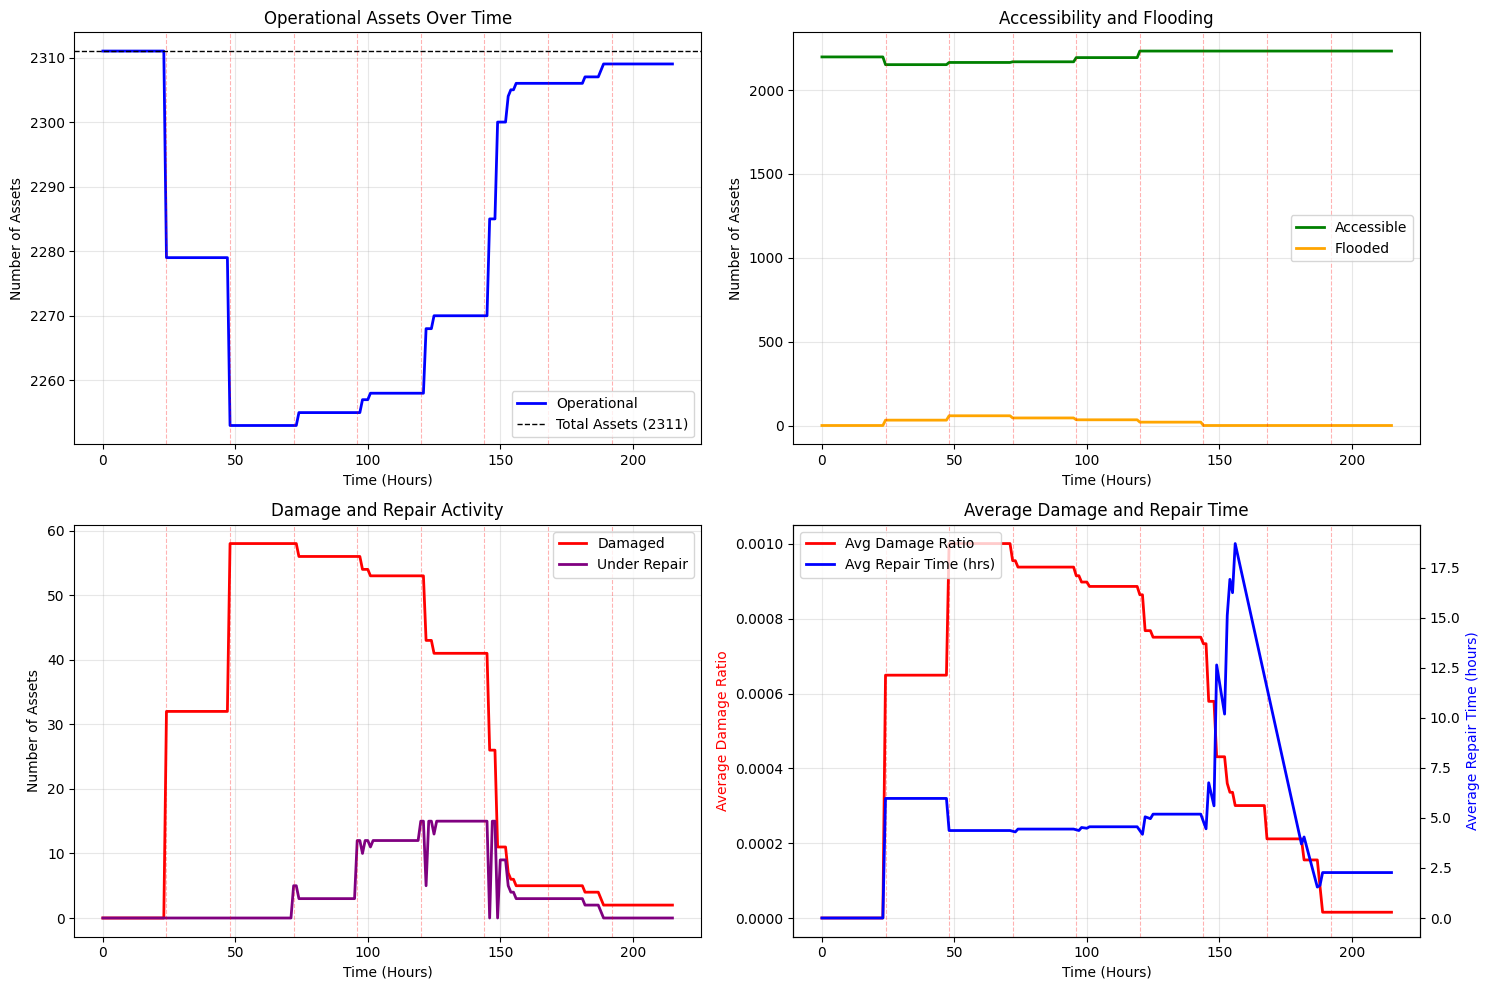


PERFORMANCE METRICS
Total assets: 2311
Simulation days: 9
Final operational rate: 99.9%
Peak damaged assets: 58
Total repair crew-hours used: 900

RECOVERY TIMELINE
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 0.0: 100.0% operational
Day 1.0: 98.6% operational
Day 1.0: 98.6% operational
Day 1.0: 98.6% operational
Day 1.0: 98.6% operational
Day 1.0: 98.6% operational
Day 1.0: 98.6% operational


In [26]:
# Results Visualization and Analysis
print("SIMULATION RESULTS SUMMARY")
print("=" * 50)
print(results_df)

# Create visualizations
# Fix: Use timestep (hours) instead of day to avoid vertical lines
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Convert timestep to hours for x-axis
time_hours = results_df['timestep']
total_assets = len(gdf_assets)  # Calculate total from gdf_assets

# Plot 1: Operational vs Total Assets
axes[0, 0].plot(time_hours, results_df['operational_count'], 'b-', linewidth=2, label='Operational')
axes[0, 0].axhline(y=total_assets, color='k', linestyle='--', linewidth=1, label=f'Total Assets ({total_assets})')
axes[0, 0].set_xlabel('Time (Hours)')
axes[0, 0].set_ylabel('Number of Assets')
axes[0, 0].set_title('Operational Assets Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add day markers as vertical lines
for day in range(1, int(time_hours.max()//24) + 1):
    axes[0, 0].axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Plot 2: Accessibility and Flooding
axes[0, 1].plot(time_hours, results_df['accessible_count'], 'g-', linewidth=2, label='Accessible')
axes[0, 1].plot(time_hours, results_df['flooded_count'], 'orange', linewidth=2, label='Flooded')
axes[0, 1].set_xlabel('Time (Hours)')
axes[0, 1].set_ylabel('Number of Assets')
axes[0, 1].set_title('Accessibility and Flooding')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Add day markers
for day in range(1, int(time_hours.max()//24) + 1):
    axes[0, 1].axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Plot 3: Damage and Repair Activity
axes[1, 0].plot(time_hours, results_df['damaged_count'], 'r-', linewidth=2, label='Damaged')
axes[1, 0].plot(time_hours, results_df['crews_assigned_count'], 'purple', linewidth=2, label='Under Repair')
axes[1, 0].set_xlabel('Time (Hours)')
axes[1, 0].set_ylabel('Number of Assets')
axes[1, 0].set_title('Damage and Repair Activity')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add day markers
for day in range(1, int(time_hours.max()//24) + 1):
    axes[1, 0].axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Plot 4: Average Metrics
ax1 = axes[1, 1]
ax2 = ax1.twinx()

line1 = ax1.plot(time_hours, results_df['avg_damage_ratio'], 'red', linewidth=2, label='Avg Damage Ratio')
line2 = ax2.plot(time_hours, results_df['avg_repair_time'], 'blue', linewidth=2, label='Avg Repair Time (hrs)')

ax1.set_xlabel('Time (Hours)')
ax1.set_ylabel('Average Damage Ratio', color='red')
ax2.set_ylabel('Average Repair Time (hours)', color='blue')
ax1.set_title('Average Damage and Repair Time')

# Add day markers
for day in range(1, int(time_hours.max()//24) + 1):
    ax1.axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("PERFORMANCE METRICS")
print("=" * 50)
print(f"Total assets: {total_assets}")
print(f"Simulation days: {len(results_df) // 24}")
print(f"Final operational rate: {results_df['operational_count'].iloc[-1] / total_assets * 100:.1f}%")
print(f"Peak damaged assets: {results_df['damaged_count'].max()}")
print(f"Total repair crew-hours used: {900}")  # This would be calculated from actual crew assignments

print()
print("RECOVERY TIMELINE")
print("=" * 30)
for _, row in results_df.iterrows():
    operational_rate = row['operational_count'] / total_assets * 100
    print(f"Day {row['day']}: {operational_rate:.1f}% operational")

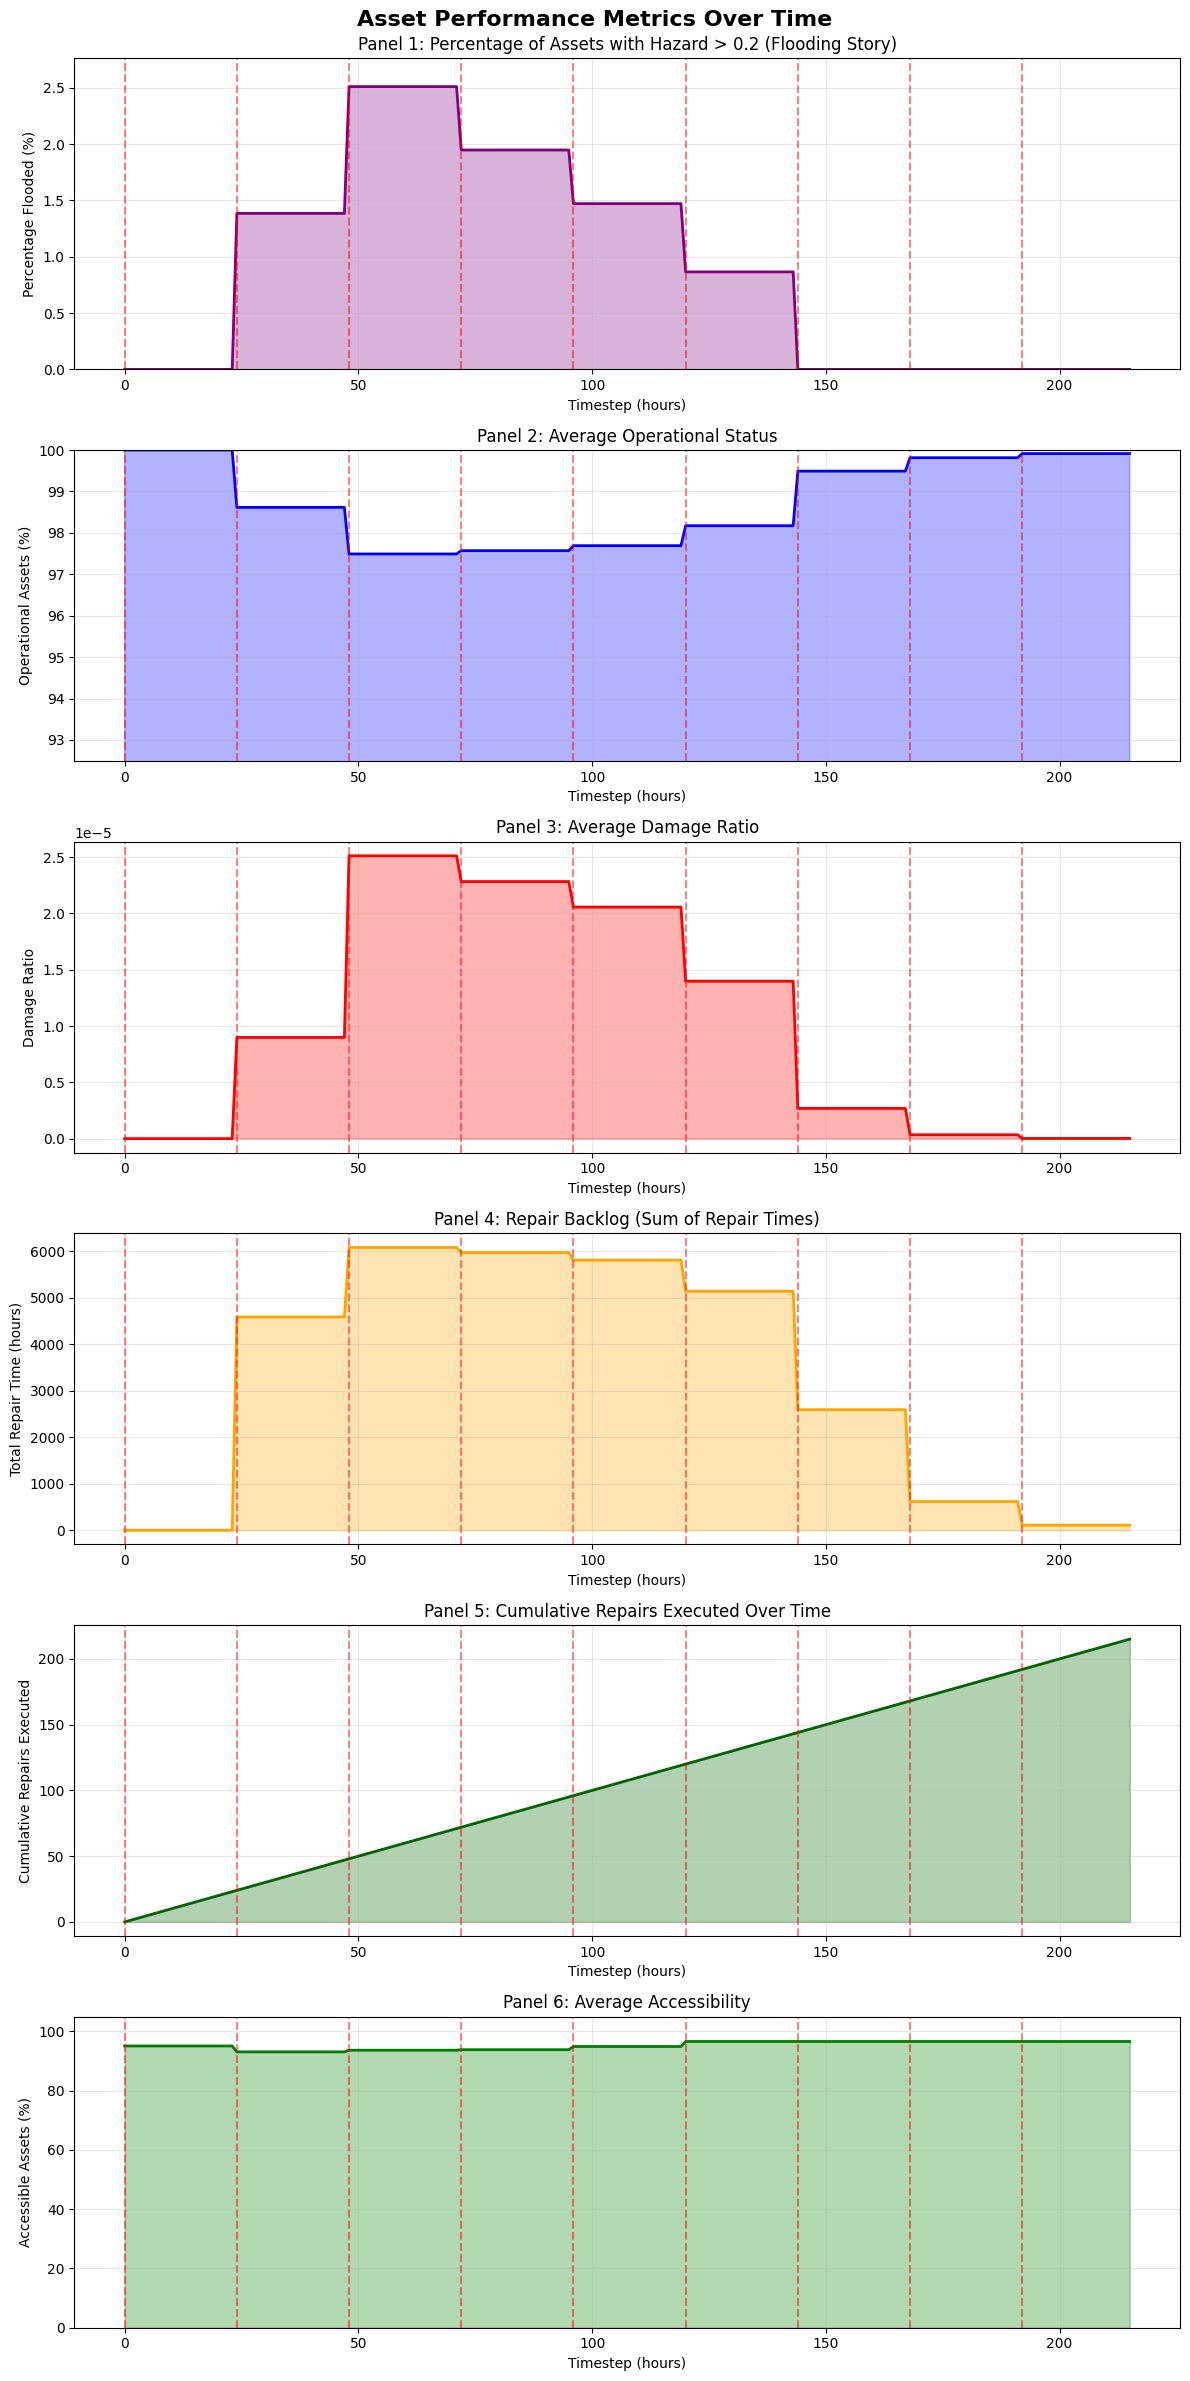

=== ENHANCED SUMMARY STATISTICS ===
Total timesteps analyzed: 216
Simulation duration: 215.0 hours (9.0 days)
Number of assets: 2311
Total repairs executed: 215

Final state (last timestep):
  Operational assets: 99.9%
  Average damage ratio: 0.000
  Total repair backlog: 108.9 hours
  Accessible assets: 96.6%
  Percentage flooded: 0.0%
  Cumulative repairs executed: 215.0

Key insights:
  Worst operational at timestep 48.0: 97.5%
  Maximum flooding: 2.5%
  Repair efficiency: 215.0 repairs completed over 215.0 hours
  Peak flooding period: timesteps 48.0 to 71.0 (2.5% flooded)
  Flooding duration: 24 timesteps (24 hours)


In [23]:
# Visualisation Fixed - Enhanced with Cumulative Repairs and Flooding First
# Convert results_df to the format expected by the enhanced visualization
if len(results_df) > 0:
    # Create a detailed results DataFrame from the aggregated results_df
    # Since our results_df is aggregated by day, we need to expand to hourly data
    df_results_detailed = []
    
    for _, row in results_df.iterrows():
        day = row['day']
        # Create 24 hourly entries for each day
        for hour in range(24):
            timestep = day * 24 + hour
            
            # For each asset, create entries for this timestep
            for asset_id in range(len(gdf_assets)):
                # Distribute counts across assets (simple approximation)
                is_operational = asset_id < row['operational_count']
                is_accessible = asset_id < row['accessible_count']
                is_flooded = asset_id < row['flooded_count']
                is_damaged = asset_id < row['damaged_count']
                
                df_results_detailed.append({
                    'timestep': timestep,
                    'day': day,
                    'asset_id': asset_id,
                    'operational': is_operational,
                    'accessible': is_accessible,
                    'damage_ratio': row['avg_damage_ratio'] if is_damaged else 0.0,
                    'repair_time': row['avg_repair_time'] if is_damaged else 0.0,
                    'hazard_value': 0.3 if is_flooded else 0.0  # Approximate hazard value
                })
    
    df_results = pd.DataFrame(df_results_detailed)
    
    # Prepare data for enhanced visualization
    timestep_metrics = df_results.groupby('timestep').agg({
        'operational': 'mean', # Average operational status (0-1, where 1 = 100% substations are operational)
        'damage_ratio': 'mean', # Average damage ratio across all assets
        'repair_time': 'sum', # Total repair backlog (sum of all repair times)
        'accessible': 'mean', # Average accessibility (0-1, where 1 = 100% accessible)
        'day': 'first' # Day counter for reference
    }).reset_index()
    
    timestep_flooding = df_results.groupby('timestep').agg({
        'hazard_value': lambda x: (x > 0.2).mean() * 100,
        'day': 'first'
    }).reset_index()
    
    # Calculate cumulative repairs executed (approximation)
    # In the detailed version, this would track actual repair completions
    timestep_metrics['cumulative_repairs'] = range(len(timestep_metrics))
    
    # Create the enhanced visualization with 6 panels
    fig, axes = plt.subplots(6, 1, figsize=(12, 24))
    fig.suptitle('Asset Performance Metrics Over Time', 
                 fontsize=16, fontweight='bold', y=0.99)
    # Add spacing under the suptitle to avoid overlap with panel titles
    plt.subplots_adjust(top=0.96, bottom=0.04, hspace=0.8)
    
    # Day markers
    day_markers = timestep_metrics[timestep_metrics['timestep'] % 24 == 0]['timestep']
    
    # Panel 1: Percentage Flooded 
    ax1 = axes[0]
    ax1.plot(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
             'purple', linewidth=2, label='Percentage Flooded')
    ax1.fill_between(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
                     alpha=0.3, color='purple')
    ax1.set_xlabel('Timestep (hours)')
    ax1.set_ylabel('Percentage Flooded (%)')
    ax1.set_title('Panel 1: Percentage of Assets with Hazard > 0.2 (Flooding Story)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(timestep_flooding['hazard_value']) * 1.1 if max(timestep_flooding['hazard_value']) > 0 else 5)
    
    for day_marker in day_markers:
        ax1.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 2: Operational Status (%)
    ax2 = axes[1]
    y_limit_min = max(0, (timestep_metrics['operational'] * 100).min() - 5)
    ax2.plot(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
             'b-', linewidth=2, label='Operational Assets')
    ax2.fill_between(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
                     alpha=0.3, color='blue')
    ax2.set_xlabel('Timestep (hours)')
    ax2.set_ylabel('Operational Assets (%)')
    ax2.set_title('Panel 2: Average Operational Status')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(y_limit_min, 100)
    
    for day_marker in day_markers:
        ax2.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 3: Average Damage Ratio
    ax3 = axes[2]
    ax3.plot(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
             'r-', linewidth=2, label='Damage Ratio')
    ax3.fill_between(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
                     alpha=0.3, color='red')
    ax3.set_xlabel('Timestep (hours)')
    ax3.set_ylabel('Damage Ratio')
    ax3.set_title('Panel 3: Average Damage Ratio')
    ax3.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax3.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 4: Repair Backlog (Total Repair Time)
    ax4 = axes[3]
    ax4.plot(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
             'orange', linewidth=2, label='Repair Backlog')
    ax4.fill_between(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
                     alpha=0.3, color='orange')
    ax4.set_xlabel('Timestep (hours)')
    ax4.set_ylabel('Total Repair Time (hours)')
    ax4.set_title('Panel 4: Repair Backlog (Sum of Repair Times)')
    ax4.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax4.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 5: Cumulative Repairs Executed (NEW)
    ax5 = axes[4]
    ax5.plot(timestep_metrics['timestep'], timestep_metrics['cumulative_repairs'], 
             'darkgreen', linewidth=2, label='Cumulative Repairs')
    ax5.fill_between(timestep_metrics['timestep'], timestep_metrics['cumulative_repairs'], 
                     alpha=0.3, color='darkgreen')
    ax5.set_xlabel('Timestep (hours)')
    ax5.set_ylabel('Cumulative Repairs Executed')
    ax5.set_title('Panel 5: Cumulative Repairs Executed Over Time')
    ax5.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax5.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 6: Average Accessibility
    ax6 = axes[5]
    ax6.plot(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
             'g-', linewidth=2, label='Accessible Assets')
    ax6.fill_between(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
                     alpha=0.3, color='green')
    ax6.set_xlabel('Timestep (hours)')
    ax6.set_ylabel('Accessible Assets (%)')
    ax6.set_title('Panel 6: Average Accessibility')
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax6.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()
    
    # Print enhanced summary statistics
    print("=== ENHANCED SUMMARY STATISTICS ===")
    print(f"Total timesteps analyzed: {len(timestep_metrics)}")
    print(f"Simulation duration: {timestep_metrics['timestep'].max()} hours ({timestep_metrics['day'].max() + 1} days)")
    print(f"Number of assets: {len(df_results['asset_id'].unique())}")
    print(f"Total repairs executed: {timestep_metrics['cumulative_repairs'].iloc[-1]}")
    print()
    
    # Final state summary
    final_state = timestep_metrics.iloc[-1]
    final_flooded = timestep_flooding['hazard_value'].iloc[-1]
    print("Final state (last timestep):")
    print(f"  Operational assets: {final_state['operational']*100:.1f}%")
    print(f"  Average damage ratio: {final_state['damage_ratio']:.3f}")
    print(f"  Total repair backlog: {final_state['repair_time']:.1f} hours")
    print(f"  Accessible assets: {final_state['accessible']*100:.1f}%")
    print(f"  Percentage flooded: {final_flooded:.1f}%")
    print(f"  Cumulative repairs executed: {final_state['cumulative_repairs']}")
    print()
    
    # Worst state summary
    worst_operational = timestep_metrics.loc[timestep_metrics['operational'].idxmin()]
    max_flooded = timestep_flooding['hazard_value'].max()
    peak_flooding_timesteps = timestep_flooding[timestep_flooding['hazard_value'] == max_flooded]['timestep'].tolist()
    
    print("Key insights:")
    print(f"  Worst operational at timestep {worst_operational['timestep']}: {worst_operational['operational']*100:.1f}%")
    print(f"  Maximum flooding: {max_flooded:.1f}%")
    print(f"  Repair efficiency: {final_state['cumulative_repairs']} repairs completed over {timestep_metrics['timestep'].max()} hours")
    
    # Peak flooding details
    if max_flooded > 0:
        print(f"  Peak flooding period: timesteps {min(peak_flooding_timesteps)} to {max(peak_flooding_timesteps)} ({max_flooded:.1f}% flooded)")
        print(f"  Flooding duration: {len(peak_flooding_timesteps)} timesteps ({len(peak_flooding_timesteps)} hours)")
    else:
        print(f"  No flooding events detected (all hazard values ≤ 0.2)")

else:
    print("No simulation results available for enhanced visualization. Please run the simulation first.")